# Algebraic Loop System

This tutorial demonstrates how SysSimX detects and solves algebraic loops.

We build a small feedback system with a direct-feedthrough loop and compare the simulation to an analytic reference.

![System Diagram](figures/algebraic_loop_graph.svg)

## Overview

An algebraic loop occurs when outputs depend instantaneously on inputs in a cycle.

SysSimX detects such loops using dependency graphs and solves them iteratively during each time step.

## Learning Goals

- Identify an algebraic loop created by direct feedthrough
- Understand how SysSimX computes execution order and resolves loops
- Simulate a system with an algebraic loop and compare to a reference solution


### Interface Jacobian-based Algorithm

The `syssimx` library implements a modeification of the Interface Jacobian-based Co-Simulation Algorithm accordinfg to Sicklinger et al. (2014) for solving algebraic loops.

The key steps of the algorithm are shown in the figure below:

![Interface Jacobian-based Algorithm](figures/ijcsa_algorithm.svg)

**References:**

S. Sicklinger, V. Belsky, B. Engelmann, H. Elmqvist, H. Olsson, R. Wüchner, and K.-U. Bletzinger.  
**Interface Jacobian-based Co-Simulation.**  
*International Journal for Numerical Methods in Engineering*, 98(4):418–444, 2014.  
[doi:10.1002/nme.4637.](https://onlinelibrary.wiley.com/doi/abs/10.1002/nme.4637)

## Prerequisites and Setup

We require the following packages:
- `syssimx`
- `numpy`
- `matplotlib`
- `graphviz` (for visualization)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from syssimx import CoSimComponent, Connection, System
from syssimx.core import PortSpec, PortType
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Implementation

We define a constant source, two subtractors, and an integrator.

The **inner subtractor** has **direct feedthrough** and a **self-loop on its input**, which creates an **algebraic loop**.


### `ConstantSource` Component

Outputs a fixed value.


In [2]:
class ConstantSource(CoSimComponent):
    """A source component that outputs a constant value."""

    def __init__(self, name: str, value: float = 1.0):
        super().__init__(name, group="Source")
        self.value = value
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None):
        self.outputs["y"].set(self.value, t)

### `Subtractor` Component

Computes `pos - neg`.

Because the output depends directly on its inputs, this component has direct feedthrough and participates in algebraic loops.


In [3]:
class Subtractor(CoSimComponent):
    """A subtractor component that subtracts its two input signals.
    
    diff = input1 - input2
    """
    def __init__(self, name="Subtractor"):
        super().__init__(name, group="Subtractor")
        self.input_specs.update({
            "pos": PortSpec("pos", PortType.REAL, direction="in"),
            "neg": PortSpec("neg", PortType.REAL, direction="in"),
        })
        self.output_specs.update({"diff": PortSpec("diff", PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None):
        """Update the output port states based on the current input values."""
        input1_value = self.inputs["pos"].get()
        input2_value = self.inputs["neg"].get()
        self.result = input1_value - input2_value
        self.outputs["diff"].set(self.result, t)

    def evaluate_outputs(self, inputs) -> dict:
        """Evaluate outputs based on given inputs."""
        i1 = inputs.get("pos", self.inputs["pos"].get())
        i2 = inputs.get("neg", self.inputs["neg"].get())
        self.outputs["diff"].set(i1 - i2, None)
        return {"diff": i1 - i2}

    def reset(self):
        super().reset()
        self.outputs["diff"].set(0.0)

### `Integrator` Component

Accumulates its input over time using explicit Euler stepping.


In [4]:
class Integrator(CoSimComponent):
    """ An integrator component that integrates its input signal u over time.

    The output y(t) is the integral of the input u(t) with respect to time
    """

    def __init__(self, name="Integrator", x0=0.0):
        super().__init__(name, group="Integrator")
        self.input_specs.update({"u": PortSpec(name="u", type=PortType.REAL, direction="in")})
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out", unit=None, description="Integrated output")})
        self.x0 = x0

    def _initialize_component(self, t0: float) -> None:
        """Initialize the integrator state."""
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        """Perform a simulation step by integrating the input signal."""
        u = self.inputs["u"].get()
        self.x += u * dt

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None):
        """Update the output port states."""
        self.outputs["y"].set(self.x, t)

    def reset(self):
        """Reset the integrator state to the initial value."""
        super().reset()
        self.x = self.x0
        self._update_output_states(self.t)

## Instantiation of Components

We create two subtractors: an **outer** subtractor for feedback and an **inner** subtractor that participates in the algebraic loop.


In [5]:
constant_source = ConstantSource(name="ConstSource", value=1.0)

subtractor_inner = Subtractor(name="InnerSubtractor")
subtractor_inner.group = "Algebraic Loop"

subtractor_outer = Subtractor(name="OuterSubtractor")
subtractor_outer.group = "Feedback"

integrator = Integrator(name="Integrator", x0=0.0)

components = [constant_source, subtractor_inner, subtractor_outer, integrator]

## Defining Connections

The inner subtractor feeds its own negative input, which makes its output implicitly defined:

- `diff_inner = pos_inner - diff_inner`
- Therefore `diff_inner = 0.5 * pos_inner`

This direct-feedthrough self-loop creates an algebraic loop that SysSimX must solve.


In [6]:
# Define connections
c1 = Connection(
    src_comp=constant_source.name,
    src_port=constant_source.output_specs["y"].name,
    dst_comp=subtractor_outer.name,
    dst_port=subtractor_outer.input_specs["pos"].name,
)

c2 = Connection(
    src_comp=subtractor_outer.name,
    src_port=subtractor_outer.output_specs["diff"].name,
    dst_comp=subtractor_inner.name,
    dst_port=subtractor_inner.input_specs["pos"].name,
)
# Algebraic loop connections
c3 = Connection(
    src_comp=subtractor_inner.name,
    src_port=subtractor_inner.output_specs["diff"].name,
    dst_comp=integrator.name,
    dst_port=integrator.input_specs["u"].name,
)

c4 = Connection(
    src_comp=subtractor_inner.name,
    src_port=subtractor_inner.output_specs["diff"].name,
    dst_comp=subtractor_inner.name,
    dst_port=subtractor_inner.input_specs["neg"].name,
)

# Feedback from integrator output to subtractor_outer
c5 = Connection(
    src_comp=integrator.name,
    src_port=integrator.output_specs["y"].name,
    dst_comp=subtractor_outer.name,
    dst_port=subtractor_outer.input_specs["neg"].name,
)

connections = [c1, c2, c3, c4, c5]

## Creating the System

We add components and connections, then initialize the system. Initialization includes loop detection and solving for a consistent initial state.


### Enabling Logging

SysSimX uses Python's standard `logging` module with a `NullHandler` at the package root — no output is produced unless you explicitly configure a handler in your application.

The following loggers are available:

| Logger name | Content |
|---|---|
| `syssimx.system.algorithms.ijcsa` | Algebraic-loop solver iterations and convergence |
| `syssimx.system.algorithms.hybrid` | Hybrid simulation algorithm events |
| `syssimx.core.history` | History save / load messages |
| `syssimx.core.multi_comp` | Multi-model component mode switching |

Setting the `syssimx` logger to `DEBUG` activates all of them at once.
For fine-grained control, configure individual sub-loggers instead.

> **Tip:** Use `%(module)s` in the format string to display only the filename
> (e.g. `[ijcsa]`) instead of the full dotted path. The hierarchical logger
> *names* are preserved for filtering — only the *display* is shortened.

In [7]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

In [8]:
# Create system and add components and connections
system = System(name="Algebraic Loop System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

[ijcsa] DEBUG: Solving algebraic SCC ['InnerSubtractor']:
[ijcsa] DEBUG: Interface inputs: [('InnerSubtractor', 'neg')]
[ijcsa] DEBUG: Internal zero-delay connections [('InnerSubtractor', 'diff', 'InnerSubtractor', 'neg')]
[ijcsa] DEBUG: External zero-delay inputs [('OuterSubtractor', 'diff', 'InnerSubtractor', 'pos')]
[ijcsa] DEBUG: Initial guess for InnerSubtractor.neg = -0.001
[ijcsa] DEBUG: Starting IJCSA iterations:
[ijcsa] DEBUG:   Iteration 0: u = [-0.001]
[ijcsa] DEBUG:     Residual for InnerSubtractor.neg: -1.0019999999999998
[ijcsa] DEBUG:     Residual for InnerSubtractor.neg: -1.001998
[ijcsa] DEBUG:     Jacobian J = [[2.]]
[ijcsa] DEBUG:     Correction Δu = [0.501]
[ijcsa] DEBUG:   Iteration 1: u = [0.5]
[ijcsa] DEBUG:     Residual for InnerSubtractor.neg: 8.243095095394892e-11
[ijcsa] DEBUG:   Converged in 1 iterations.
[ijcsa] DEBUG: Committed solved input InnerSubtractor.neg = 0.5000000000412155


The debug output above shows the IJCSA solver at work:

1. It identifies the algebraic SCC containing `InnerSubtractor`
2. It lists the interface inputs and internal zero-delay connections
3. It iterates (Newton step) until the residual is below tolerance
4. It commits the converged input values

To silence the output again, raise the log level:

In [9]:
# Silence syssimx logging for the rest of the notebook
logging.getLogger("syssimx").setLevel(logging.WARNING)

## Visualizing the System Graph

The system graph highlights the algebraic loop. Direct-feedthrough outputs are shown in red.


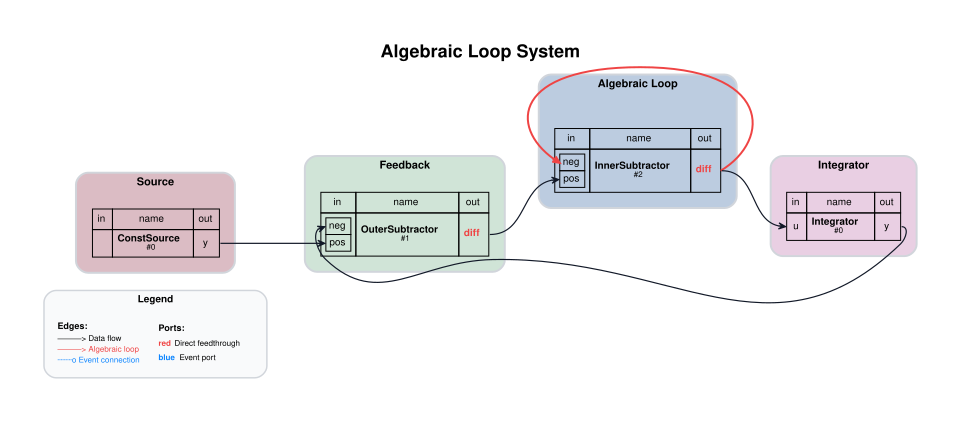

In [10]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

## Initial Consistent State

After initialization, SysSimX has solved the algebraic loop to produce consistent outputs.


In [11]:
print(60 * "=", "\nInitial consistent system state:")
print("Source;           ", constant_source.get_outputs())
print("Outer Subtractor: ", subtractor_outer.get_outputs())
print("Inner Subtractor: ", subtractor_inner.get_outputs())
print("Integrator:       ", integrator.get_outputs())

Initial consistent system state:
Source;            {'y': 1.0}
Outer Subtractor:  {'diff': 1.0}
Inner Subtractor:  {'diff': 0.4999999999587845}
Integrator:        {'y': 0.0}


## Running the Simulation

We simulate for 10 seconds with a fixed time step.


In [12]:
t0 = 0.0
tf = 10.0
dt = 0.01

system.run(t0=t0, tf=tf, dt=dt)

## Retrieving History

We plot the integrator output and the inner subtractor output.


In [13]:
history = system.get_history()
t_integrator, data_integrator = history['Integrator']
y_integrator = data_integrator['y']
t_inner_subtractor, data_inner_subtractor = history['InnerSubtractor']
diff_inner_subtractor = data_inner_subtractor['diff']


## Reference Solution

The system reduces to the ODE:

$$
\dot{y} = 0.5 \,(1 - y), \quad y(0) = 0
$$

with analytic solution:

$$
y(t) = 1 - e^{-0.5 t}
$$


In [14]:
dt_ref = dt / 100
t_ref = np.arange(t0, tf + dt_ref, dt_ref)
y_ref = 1 - np.exp(-0.5 * t_ref)

## Visualizing the Results

The figure below shows the integrator output converging to the reference solution, demonstrating that SysSimX successfully solved the algebraic loop at each time step.

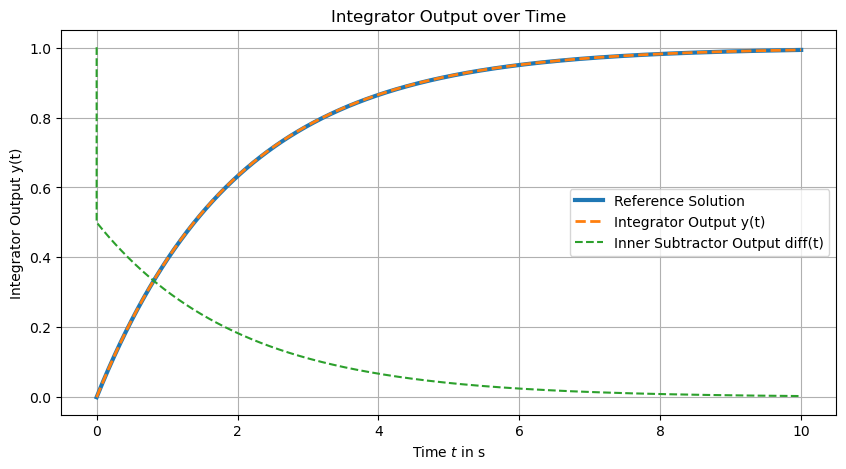

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(t_ref, y_ref, label='Reference Solution', linestyle='-', linewidth=3)
plt.plot(t_integrator, y_integrator, label='Integrator Output y(t)', linestyle='--', linewidth=2)
plt.plot(t_inner_subtractor, diff_inner_subtractor,'--', label='Inner Subtractor Output diff(t)')
plt.title('Integrator Output over Time')
plt.xlabel(r'Time $t$ in s')
plt.ylabel('Integrator Output y(t)')
plt.legend()
plt.grid()
plt.show()

## Conclusion

This example shows how SysSimX detects and resolves algebraic loops automatically, allowing stable simulation of coupled direct-feedthrough components.
